In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import json
import sys

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [ ]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
from scripts.preprocessing_custom import FrequencyEncoder, TargetEncoder

In [5]:
from scripts.preprocessing_custom import FrequencyEncoder, TargetEncoder

In [6]:
DATA_DIR = Path('../data/companies')

# Base table (row reference)
df_base = pd.read_csv(DATA_DIR / "company_features_processed_base.csv")

# Prospecting feature space
X_pros = np.load(DATA_DIR / "prospecting/X_prospect_features.npy")

with open(DATA_DIR / "prospecting/feature_names_prospect.json") as f:
    pros_feature_names = f.read()

pros_pre = joblib.load(DATA_DIR / "prospecting/preprocessor_prospect.joblib")

print("Base table shape:", df_base.shape)
print("Prospecting feature matrix shape:", X_pros.shape)


Base table shape: (908, 115)
Prospecting feature matrix shape: (908, 313)


In [7]:
df_customers = df_base.copy()
X_cust = X_pros

In [8]:
print("Customers:", X_cust.shape[0])

Customers: 908


## PCA

In [9]:
pca_full = PCA(random_state=42)
pca_full.fit(X_cust)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

for i in [5, 10, 15, 20, 30, 40]:
  print(f"{i:>} components -> {cum_var[i-1]:.3f} explained variance")

5 components -> 0.717 explained variance
10 components -> 0.892 explained variance
15 components -> 0.931 explained variance
20 components -> 0.942 explained variance
30 components -> 0.953 explained variance
40 components -> 0.961 explained variance


In [10]:
N_COMPNENTS = 20

pca = PCA(n_components=N_COMPNENTS, random_state=42)
Z_cust = pca.fit_transform(X_cust)

print("Cutomer manifold shape:", Z_cust.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

Cutomer manifold shape: (908, 20)
Explained variance: 0.9420884292010407


### Define Customer Likeness

In [11]:
K = 10

knn = NearestNeighbors(
  n_neighbors=K,
  metric="euclidean"
)

knn.fit(Z_cust)

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


Stability check

In [12]:
distances, indices = knn.kneighbors(Z_cust)

print("Mean self-distance:", distances.mean())
print("Median self-distance:", np.median(distances))

Mean self-distance: 1.5952748770726186
Median self-distance: 1.6034322924443445


In [13]:
def score_candidates(df_candidates):
    """
    Score candidate companies by similarity to customer manifold.
    Returns dataframe with distances and nearest customers.
    """
    X_new = pros_pre.transform(df_candidates)
    Z_new = pca.transform(X_new)

    distances, indices = knn.kneighbors(Z_new)

    out = df_candidates.copy()
    out["knn_mean_distance"] = distances.mean(axis=1)
    out["knn_median_distance"] = np.median(distances, axis=1)

    out["nearest_customers"] = [
        df_customers.iloc[idx]["company"].tolist()
        for idx in indices
    ]

    return out.sort_values("knn_mean_distance")

Define likeness such that
$$\text{customer\_likeness}(x) = 1 - \text{percentile}\big(\bar d(x)\big)$$

In [14]:
from scipy.stats import rankdata

def add_customer_likeness(df_scored, distance_col="knn_mean_distance"):
  ranks = rankdata(df_scored[distance_col], method="average")
  pct = ranks / len(ranks)
  df_scored["customer_likeness"] = 1.0 - pct
  return df_scored
  

Score existing customers

In [15]:
df_cust_scored = score_candidates(df_customers)
df_cust_scored = add_customer_likeness(df_cust_scored)

df_cust_scored[[
  "company",
  "knn_mean_distance",
  "knn_median_distance"
]].head()


/Users/q/PythonScript/Python/Vibe/products/ksp-packaging-estimator/scripts/preprocessing_custom.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = X[c].astype("object").fillna("__MISSING__")


,company,knn_mean_distance,knn_median_distance
890,WINGBINDERS,0.000087,0.000087
687,REFELX,0.000087,0.000087
736,SHAUN-CHEQUERS,0.000087,0.000087
188,CONSERTATREE,0.000087,0.000087
157,CHRISTIE-JLR,0.000087,0.000087


In [27]:
def assign_prospect_tier(x):
    if x >= 0.95:
        return "Tier A (Top 5%)"
    elif x >= 0.85:
        return "Tier B (Top 15%)"
    elif x >= 0.70:
        return "Tier C (Top 30%)"
    else:
        return "Low priority"

df_cust_scored["prospect_tier"] = df_cust_scored["customer_likeness"].apply(assign_prospect_tier)

df_cust_scored["prospect_tier"].value_counts()

prospect_tier
Low priority        636
Tier C (Top 30%)    136
Tier B (Top 15%)     91
Tier A (Top 5%)      45
Name: count, dtype: int64

In [16]:
df_cust_scored["customer_likeness"].describe()

count    908.000000
mean       0.499449
std        0.288834
min        0.000000
25%        0.249725
50%        0.499449
75%        0.749174
max        0.993943
Name: customer_likeness, dtype: float64

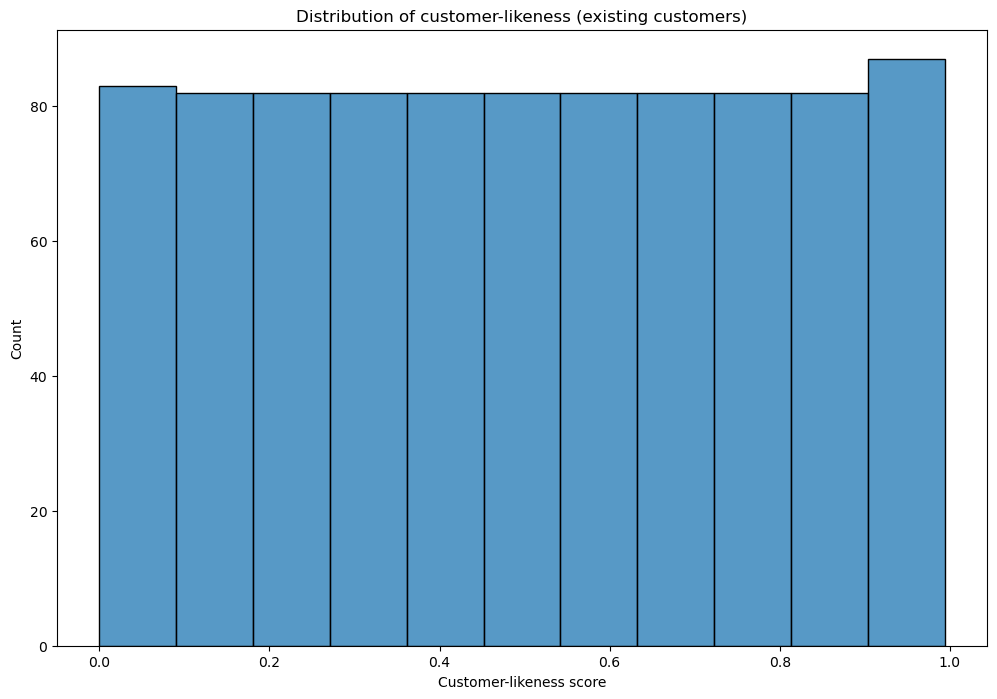

In [22]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(12,8))
sns.histplot(
  df_cust_scored["customer_likeness"]
)

plt.xlabel("Customer-likeness score")
plt.ylabel("Count")
plt.title("Distribution of customer-likeness (existing customers)")
plt.show()

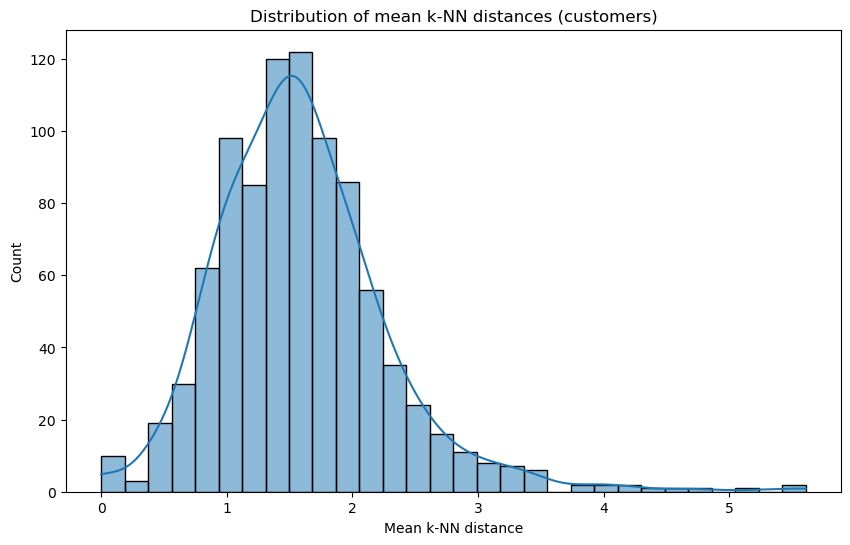

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df_cust_scored["knn_mean_distance"],
    bins=30,
    kde=True
)
plt.xlabel("Mean k-NN distance")
plt.ylabel("Count")
plt.title("Distribution of mean k-NN distances (customers)")
plt.show()

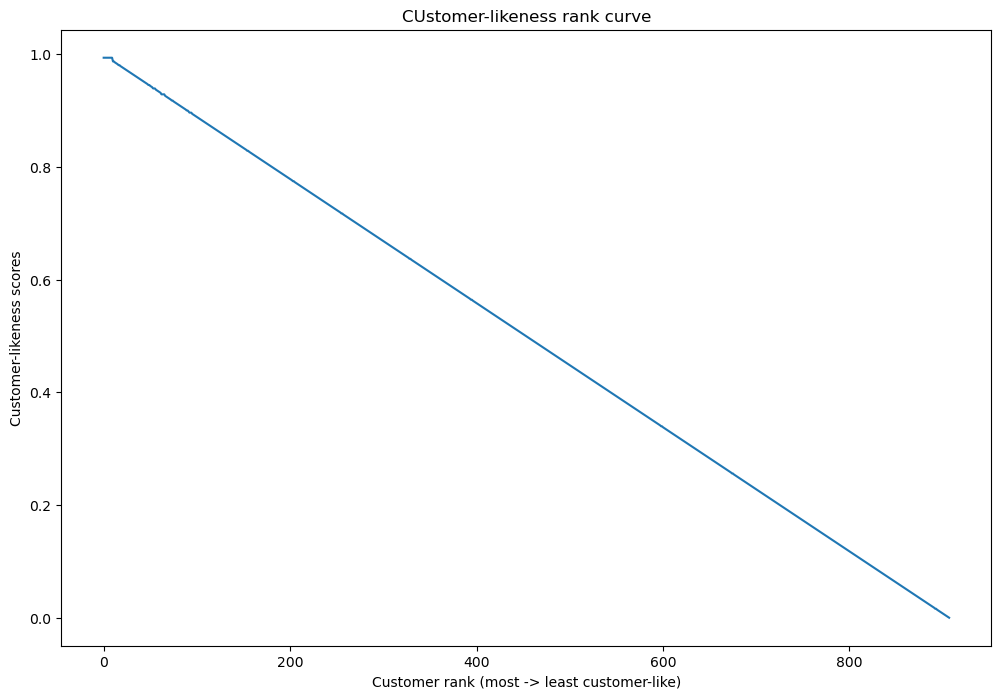

In [ ]:
df_sorted = df_cust_scored.sort_values("customer_likeness", ascending=False).reset_index(drop=True)
plt.figure(figsize=(12,8))
plt.plot(df_sorted["customer_likeness"].values)
plt.xlabel("Customer rank (most -> least customer-like)")
plt.ylabel("Customer-likeness scores")
plt.title("Customer-likeness rank curve")
plt.show()

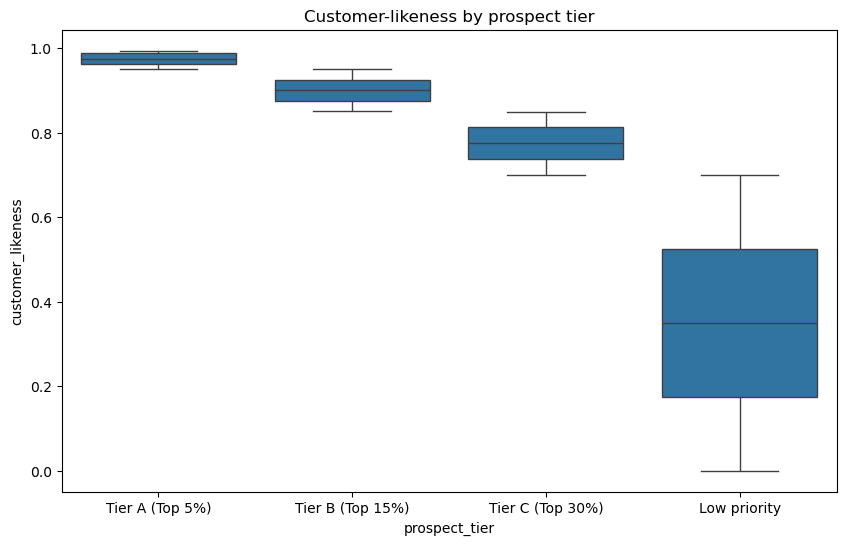

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cust_scored,
    x="prospect_tier",
    y="customer_likeness",
    order=["Tier A (Top 5%)", "Tier B (Top 15%)", "Tier C (Top 30%)", "Low priority"]
)
plt.title("Customer-likeness by prospect tier")
plt.show()

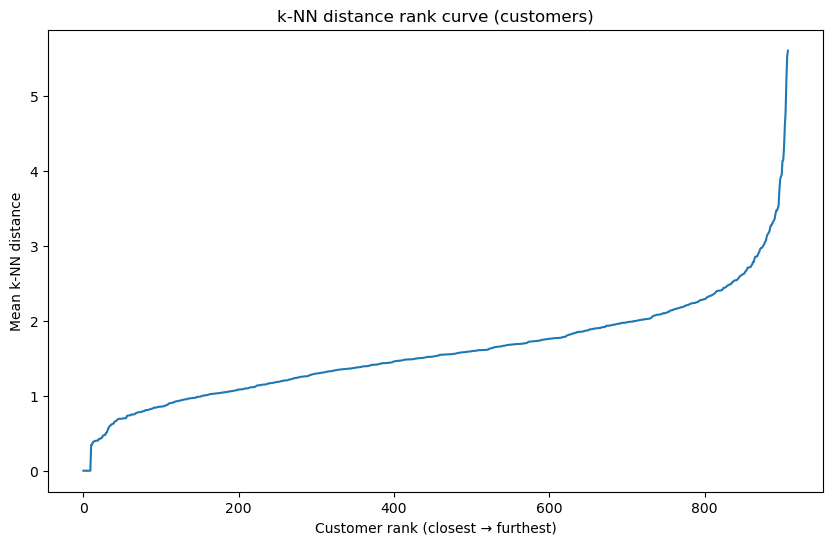

In [30]:
df_sorted = df_cust_scored.sort_values("knn_mean_distance")

plt.figure(figsize=(10, 6))
plt.plot(df_sorted["knn_mean_distance"].values)
plt.xlabel("Customer rank (closest → furthest)")
plt.ylabel("Mean k-NN distance")
plt.title("k-NN distance rank curve (customers)")
plt.show()

Instead of choosing tiers by percentile alone, we can now justify them geometrically.

For example (approximate from the plot):
	•	Core customers:
mean k-NN distance ≲ 2.0
(~top 65–70% of customers)
	•	Extended / niche customers:
distance ≈ 2.0–2.7
(~next 20%)
	•	Edge / atypical customers:
distance ≳ 2.7–3.0

That gives us a distance-based threshold we can defend to a non-technical audience:

“Beyond this point, companies stop looking like our typical customers.”

This is much stronger than “top 10% because… vibes”.

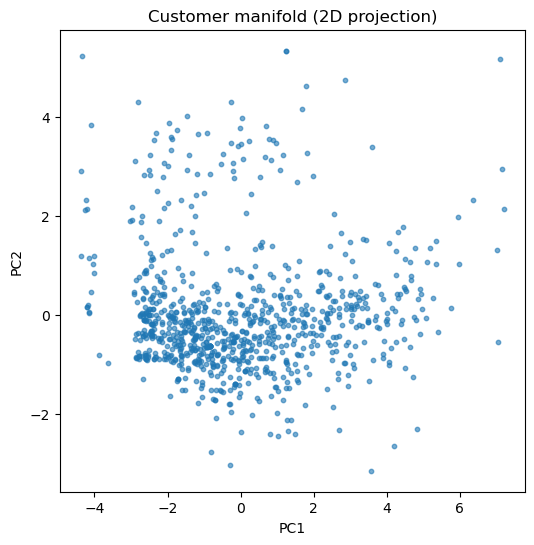

In [29]:
import matplotlib.pyplot as plt

Z_2d = PCA(n_components=2, random_state=42).fit_transform(Z_cust)

plt.figure(figsize=(6, 6))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], s=10, alpha=0.6)
plt.title("Customer manifold (2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

	•	A dense central cloud
	•	Clear anisotropy (elongation along PC1)
	•	A handful of clearly isolated points

This aligns perfectly with the distance curve:
	•	the dense cloud → flat part of the rank curve
	•	the sparse halo → rising section
	•	isolated points → steep tail

## Distance anchored tiers

In [31]:
def assign_distance_tier(d):
    if d <= 2.0:
        return "Core-like (A)"
    elif d <= 2.7:
        return "Adjacent (B)"
    elif d <= 3.5:
        return "Peripheral (C)"
    else:
        return "Off-profile"

In [32]:
cols = [
    "company",
    "customer_likeness",
    "knn_mean_distance",
    "nearest_customers"
]

df_cust_scored[cols].sample(5, random_state=42)

,company,customer_likeness,knn_mean_distance,nearest_customers
44,ARTHUR GODDARD,0.046256,2.856911,"[ARTHUR GODDARD, HAGUE PRINT, SEACOURT PRESS, ..."
141,CDT,0.515419,1.510631,"[CDT, PPS PRINT, GRAYS LONDON, PIXEL, HARDINGS..."
62,BAMBOO CREATIONS,0.622247,1.363155,"[BAMBOO CREATIONS, CLAROPRINT, SHERWOOD GROUP,..."
906,ZENITH,0.188326,2.074656,"[ZENITH, NORDIC, OXFORD, THE COLOUR COMPANY, P..."
65,BANBURY LITH0,0.134361,2.238054,"[BANBURY LITH0, AMY FINNIMORE SLEEVE &, AMY FI..."


### Save the artefacts

In [33]:
import json
from pathlib import Path
import joblib

OUT_DIR = Path("../data/companies/prospecting_knn")
OUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pca, OUT_DIR / "pca.joblib")
joblib.dump(knn, OUT_DIR / "knn.joblib")

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump({
        "n_components": pca.n_components_,
        "k": K,
        "n_customers": Z_cust.shape[0]
    }, f, indent=2)

print("Saved prospecting manifold artefacts.")

Saved prospecting manifold artefacts.


### Evalute Candidates

In [ ]:
df_candidates

In [ ]:
df_prospects = score_candidates(df_candidates)
df_prospects = add_customer_likeness(df_prospects)

df_prospects["prospect_tier"] = df_prospects["customer_likeness"].apply(assign_prospect_tier)

df_prospects.sort_values("customer_likeness", ascending=False).head(20)